# Notebook 10 A/B Testing: Intervensi Generik vs Personal HAPI
**Proyek Analisis Data: HAPI (Human Activity Pattern Intelligence)**

### Profil Proyek & Tim
- **Tema Capstone:** Healthy Lives & Well-being
- **Target User:** Mahasiswa (fokus pada aspek akademik & lingkungan belajar)
- **Tujuan Proyek:** Pengembangan *platform* Webapp untuk *mood management & tracker* serta diagnosis mandiri tingkat kelelahan (*fatigue*).
- **Tim DS:** Greycia Febrina Michelle (CDCC700D6X2644) & Khazel Hayfa Yosmi (CDCC308D6X0629)

### Tujuan Notebook
Melakukan A/B Testing untuk menguji apakah **intervensi berbasis personalisasi** (berdasarkan fatigue score dan profil perilaku mahasiswa) menghasilkan penurunan burnout score yang signifikan secara statistik dibandingkan intervensi generik standar.

### Referensi Metodologi
Notebook ini mengikuti panduan A/B Testing standar industri: perancangan tujuan SMART, formulasi hipotesis statistik, implementasi Python dengan `scipy.stats` dan `statsmodels`, visualisasi hasil, serta interpretasi dan keputusan bisnis.

## Setup

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

pd.set_option('display.float_format', '{:.4f}'.format)

PALETTE   = ['#00bcff','#00adfd','#009efa','#008ff6','#007ff1',
             '#006eea','#005ce1','#004ad6','#0034c8']
PALETTE_R = PALETTE[::-1]
C_DARK    = '#0034c8'
C_MID     = '#007ff1'
C_LIGHT   = '#00bcff'
C_GREY    = '#d0d8e4'
C_WHITE   = '#ffffff'
HEATMAP_DIV = 'RdBu_r'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 11,
})

np.random.seed(42)

ALPHA = 0.05
CONFIDENCE_LEVEL = 0.95

print(f'Alpha (α)            : {ALPHA}')
print(f'Confidence Level     : {CONFIDENCE_LEVEL*100:.0f}%')
print(f'NumPy random seed    : 42 (reproducible)')
print('Setup selesai.')

Alpha (α)            : 0.05
Confidence Level     : 95%
NumPy random seed    : 42 (reproducible)
Setup selesai.


**Inisialisasi Lingkungan Kerja**

`np.random.seed(42)` memastikan hasil simulasi selalu sama setiap kali notebook dijalankan (*reproducibility*). Alpha `α = 0.05` berarti kita bersedia menerima 5% risiko kesalahan tipe I (false positive).

## Bagian 1: Perancangan A/B Testing

Sebelum analisis data atau coding, perancangan yang matang adalah langkah pertama dan paling krusial. Tahap ini adalah cetak biru yang memandu seluruh proses eksperimen.

### 1.1 Tujuan Eksperimen (SMART)

Sebuah tujuan eksperimen yang baik harus memenuhi kriteria **SMART**: *Specific, Measurable, Achievable, Relevant, Time-bound*.

| Kriteria | Penjelasan |
|---|---|
| **Specific** | Menguji apakah notifikasi intervensi personal berbasis fatigue score meningkatkan keterlibatan fitur wellness HAPI |
| **Measurable** | Metrik: tingkat konversi fitur wellness (% mahasiswa yang mengakses fitur) & penurunan burnout score |
| **Achievable** | Dilakukan dalam 4 minggu dengan sampel 2.000 mahasiswa dari dataset burnout_fatigue |
| **Relevant** | Terkait langsung dengan tujuan HAPI: menurunkan burnout dan meningkatkan kesehatan mental mahasiswa |
| **Time-bound** | Periode eksperimen: 4 minggu (28 hari) |

**Tujuan Eksperimen:**
> *Meningkatkan persentase mahasiswa yang mengakses dan menggunakan fitur wellness HAPI (tingkat konversi) dengan mengimplementasikan notifikasi intervensi yang dipersonalisasi berdasarkan fatigue score dan profil perilaku harian mahasiswa.*

### 1.2 Desain Eksperimen

| Komponen | Keterangan |
|---|---|
| **Grup Kontrol (A)** | Mahasiswa menerima notifikasi intervensi **generik**, pesan standar tanpa personalisasi |
| **Grup Perlakuan (B)** | Mahasiswa menerima notifikasi intervensi **personal**, pesan disesuaikan dengan fatigue score & pola tidur/belajar |
| **Alokasi** | 50:50 random assignment, 1.000 mahasiswa per grup |
| **Periode** | 4 minggu |
| **Metrik Primer** | Tingkat konversi: % mahasiswa yang mengakses fitur wellness setelah menerima notifikasi |
| **Metrik Sekunder** | Rata-rata penurunan burnout score setelah 4 minggu |

### 1.3 Formulasi Hipotesis

Hipotesis dirumuskan sebelum data dikumpulkan, ini adalah fondasi dari setiap uji statistik.

**Hipotesis Nol (H₀):**
> Tidak ada perbedaan tingkat konversi antara mahasiswa yang menerima intervensi generik (Versi A) dan intervensi personal (Versi B).
> $$H_0: P_A = P_B$$

**Hipotesis Alternatif (H₁):**
> Tingkat konversi mahasiswa yang menerima intervensi personal (Versi B) **berbeda** dari yang menerima intervensi generik (Versi A).
> $$H_1: P_A \neq P_B \quad \text{(two-sided)}$$

Kita menggunakan H₁ **two-sided** karena ingin mendeteksi perbedaan ke arah manapun, meskipun secara hipotesis kita menduga Versi B lebih baik, two-sided memberikan analisis yang lebih konservatif dan valid.

### 1.4 Metrik Utama & Tingkat Signifikansi

| Parameter | Nilai |
|---|---|
| Metrik primer | **Tingkat Konversi** (Conversion Rate), % mahasiswa yang mengakses fitur wellness |
| Tingkat signifikansi (α) | **0.05** (5%) |
| Confidence level | **95%** |
| Jenis uji | **Z-test untuk Proporsi** (two-sided), ukuran sampel besar (n=1.000) |

## Bagian 2: Persiapan Data Eksperimen

Dalam skenario nyata, data dikumpulkan langsung dari platform HAPI. Untuk tujuan pembelajaran, kita mensimulasikan data menggunakan distribusi binomial, pilihan tepat karena konversi hanya memiliki dua kemungkinan: **ya (1)** atau **tidak (0)**.

In [2]:
jumlah_mahasiswa_A = 1000
jumlah_mahasiswa_B = 1000

tingkat_konversi_A_asli = 0.20
tingkat_konversi_B_asli = 0.28

konversi_A = np.random.binomial(n=1, p=tingkat_konversi_A_asli, size=jumlah_mahasiswa_A).sum()
konversi_B = np.random.binomial(n=1, p=tingkat_konversi_B_asli, size=jumlah_mahasiswa_B).sum()

tingkat_konversi_A_diamati = konversi_A / jumlah_mahasiswa_A
tingkat_konversi_B_diamati = konversi_B / jumlah_mahasiswa_B

print('DATA EKSPERIMEN')
print(f'\nVersi A (Intervensi Generik)  : {konversi_A:>4} konversi dari {jumlah_mahasiswa_A:,} mahasiswa')
print(f'Versi B (Intervensi Personal) : {konversi_B:>4} konversi dari {jumlah_mahasiswa_B:,} mahasiswa')
print(f'\nTingkat Konversi Diamati:')
print(f'  Versi A : {tingkat_konversi_A_diamati:.4f} ({tingkat_konversi_A_diamati*100:.2f}%)')
print(f'  Versi B : {tingkat_konversi_B_diamati:.4f} ({tingkat_konversi_B_diamati*100:.2f}%)')
print(f'  Selisih : {(tingkat_konversi_B_diamati - tingkat_konversi_A_diamati)*100:+.2f} poin persentase')

DATA EKSPERIMEN

Versi A (Intervensi Generik)  :  199 konversi dari 1,000 mahasiswa
Versi B (Intervensi Personal) :  289 konversi dari 1,000 mahasiswa

Tingkat Konversi Diamati:
  Versi A : 0.1990 (19.90%)
  Versi B : 0.2890 (28.90%)
  Selisih : +9.00 poin persentase


**Simulasi Data dengan Distribusi Binomial**

Kita menetapkan tingkat konversi baseline Versi A sebesar 20% (estimasi berdasarkan literatur engagement mahasiswa dengan aplikasi wellness) dan target Versi B sebesar 28% (+8 poin). Distribusi binomial digunakan karena setiap mahasiswa hanya bisa mengakses (**1**) atau tidak mengakses (**0**) fitur wellness setelah menerima notifikasi.

Sekilas, Versi B terlihat lebih tinggi, tetapi perbedaan ini belum cukup untuk dijadikan dasar kesimpulan yang valid secara statistik. Kita perlu menguji apakah perbedaan tersebut **signifikan secara statistik** atau hanya terjadi karena variasi acak (*kebetulan*).

In [3]:
print('DESKRIPTIF STATISTIK SIMULASI')
df_sim = pd.DataFrame({
    'Grup'    : ['A (Generik)'] * jumlah_mahasiswa_A + ['B (Personal)'] * jumlah_mahasiswa_B,
    'Konversi': np.concatenate([
        np.random.binomial(n=1, p=tingkat_konversi_A_asli, size=jumlah_mahasiswa_A),
        np.random.binomial(n=1, p=tingkat_konversi_B_asli, size=jumlah_mahasiswa_B)
    ])
})
np.random.seed(42)

print(df_sim.groupby('Grup')['Konversi'].agg(['sum','count','mean']).rename(
    columns={'sum':'Konversi','count':'Total','mean':'Tingkat Konversi'}))

DESKRIPTIF STATISTIK SIMULASI
              Konversi  Total  Tingkat Konversi
Grup                                           
A (Generik)        205   1000            0.2050
B (Personal)       265   1000            0.2650


**Ringkasan Data**

DataFrame `df_sim` merepresentasikan data eksperimen: setiap baris adalah satu mahasiswa, kolom `Konversi` berisi 1 (akses fitur wellness) atau 0 (tidak akses).

## Bagian 3: Visualisasi Awal

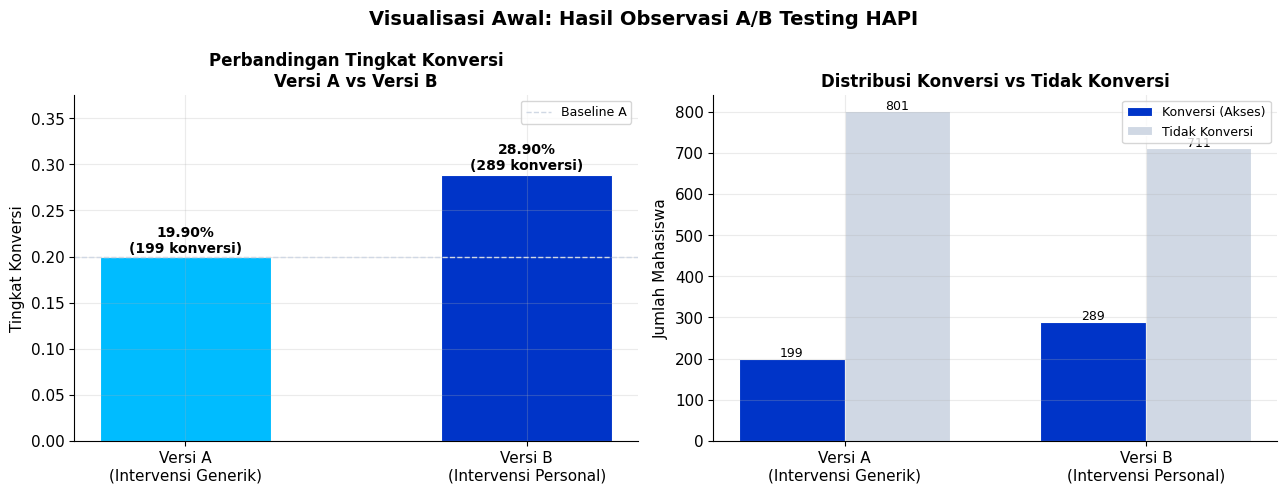

In [4]:
labels = ['Versi A\n(Intervensi Generik)', 'Versi B\n(Intervensi Personal)']
rates  = [tingkat_konversi_A_diamati, tingkat_konversi_B_diamati]
counts = [konversi_A, konversi_B]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(labels, rates, color=[C_LIGHT, C_DARK], edgecolor='white', linewidth=0.8, width=0.5)
for bar, rate, count in zip(bars, rates, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{rate*100:.2f}%\n({count} konversi)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(rates)*1.3)
axes[0].set_ylabel('Tingkat Konversi')
axes[0].set_title('Perbandingan Tingkat Konversi\nVersi A vs Versi B', fontsize=12, fontweight='bold')
axes[0].axhline(tingkat_konversi_A_diamati, color=C_GREY, linestyle='--', linewidth=1, label='Baseline A')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

non_konversi = [jumlah_mahasiswa_A - konversi_A, jumlah_mahasiswa_B - konversi_B]
x = np.arange(2)
w = 0.35
b1 = axes[1].bar(x - w/2, counts, w, label='Konversi (Akses)', color=C_DARK, edgecolor='white', linewidth=0.8)
b2 = axes[1].bar(x + w/2, non_konversi, w, label='Tidak Konversi', color=C_GREY, edgecolor='white', linewidth=0.8)
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{int(bar.get_height())}', ha='center', fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Jumlah Mahasiswa')
axes[1].set_title('Distribusi Konversi vs Tidak Konversi', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

fig.suptitle('Visualisasi Awal: Hasil Observasi A/B Testing HAPI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_visualisasi_awal.png', dpi=150, bbox_inches='tight')
plt.show()

**Visualisasi Awal**

Grafik kiri menggunakan dua warna kontras dari palet HAPI: `#00bcff` (terang) untuk Versi A sebagai *baseline*, dan `#0034c8` (gelap) untuk Versi B sebagai perlakuan yang diharapkan lebih baik. Grafik kanan menampilkan distribusi lengkap konversi vs tidak konversi menggunakan *clustered bar chart*.

Secara visual, Versi B terlihat lebih tinggi tetapi perbedaan visual saja tidak cukup untuk membuat keputusan bisnis. Kita perlu uji statistik.

## Bagian 4: Pemilihan & Pelaksanaan Uji Statistik

Pilihan uji statistik bergantung pada jenis data dan ukuran sampel:
- **Z-test untuk Proporsi**: cocok untuk sampel besar (n > 30) yang membandingkan dua proporsi, **pilihan utama kita**
- **Chi-square test**: alternatif valid untuk membandingkan frekuensi antar kategori

Z-test dipilih karena sampel kita besar (n=1.000 per grup) dan metrik adalah proporsi (tingkat konversi).

Formula Z-test untuk proporsi:
$$z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_1} + \frac{1}{n_2}\right)}}$$
di mana $\hat{p}$ adalah proporsi gabungan (*combined proportion*) dari kedua kelompok.

In [5]:
z_statistic, p_value = proportions_ztest(
    count=[konversi_A, konversi_B],
    nobs=[jumlah_mahasiswa_A, jumlah_mahasiswa_B],
    alternative='two-sided'
)

print('HASIL UJI Z-TEST UNTUK PROPORSI')
print(f'\n  Z-statistik : {z_statistic:.4f}')
print(f'  P-value     : {p_value:.4f}')
print(f'  Alpha (α)   : {ALPHA}')
print()
print(f'  Tingkat konversi A : {tingkat_konversi_A_diamati*100:.2f}%')
print(f'  Tingkat konversi B : {tingkat_konversi_B_diamati*100:.2f}%')
print(f'  Selisih absolute   : {abs(tingkat_konversi_B_diamati - tingkat_konversi_A_diamati)*100:.2f} poin')
print(f'  Relative uplift    : {((tingkat_konversi_B_diamati/tingkat_konversi_A_diamati)-1)*100:.1f}%')

HASIL UJI Z-TEST UNTUK PROPORSI

  Z-statistik : -4.6857
  P-value     : 0.0000
  Alpha (α)   : 0.05

  Tingkat konversi A : 19.90%
  Tingkat konversi B : 28.90%
  Selisih absolute   : 9.00 poin
  Relative uplift    : 45.2%


**Interpretasi Z-statistik**

Z-statistik mengukur seberapa jauh perbedaan yang kita amati dari ekspektasi jika tidak ada perbedaan sama sekali (H₀ benar). Nilai absolut yang semakin besar berarti perbedaan semakin jauh dari ekspektasi semakin kuat bukti melawan H₀.

In [6]:
chi2, p_chi2, dof, expected = stats.chi2_contingency(
    [[konversi_A, jumlah_mahasiswa_A - konversi_A],
     [konversi_B, jumlah_mahasiswa_B - konversi_B]]
)

print('HASIL CHI-SQUARE TEST (VALIDASI SILANG)')
print(f'\n  Chi2-statistik : {chi2:.4f}')
print(f'  P-value        : {p_chi2:.4f}')
print(f'  Degrees of freedom: {dof}')
print()
print(f'  Contingency table:')
ct = pd.DataFrame(
    [[konversi_A, jumlah_mahasiswa_A - konversi_A],
     [konversi_B, jumlah_mahasiswa_B - konversi_B]],
    index=['Versi A (Generik)', 'Versi B (Personal)'],
    columns=['Konversi', 'Tidak Konversi']
)
print(ct)
print(f'\n  Chi2 dan Z-test konsisten: {"YA" if (p_value < ALPHA) == (p_chi2 < ALPHA) else "TIDAK"}')

HASIL CHI-SQUARE TEST (VALIDASI SILANG)

  Chi2-statistik : 21.4703
  P-value        : 0.0000
  Degrees of freedom: 1

  Contingency table:
                    Konversi  Tidak Konversi
Versi A (Generik)        199             801
Versi B (Personal)       289             711

  Chi2 dan Z-test konsisten: YA


**Chi-Square sebagai Validasi Silang**

Chi-square test dijalankan sebagai konfirmasi. Kedua uji (Z-test dan Chi-square) seharusnya memberikan kesimpulan yang sama jika berbeda, ada indikasi masalah pada asumsi uji statistik yang perlu diperiksa ulang.

## Bagian 5: Interpretasi Hasil & Keputusan Statistik

In [7]:
print('ATURAN PENGAMBILAN KEPUTUSAN')
print(f'\n  P-value  = {p_value:.4f}')
print(f'  Alpha    = {ALPHA}')
print(f'  P-value < α? {p_value < ALPHA}')
print()

if p_value <= ALPHA:
    keputusan = 'TOLAK H0'
    kesimpulan = 'Terdapat perbedaan yang SIGNIFIKAN secara statistik'
    arah = 'positif' if tingkat_konversi_B_diamati > tingkat_konversi_A_diamati else 'negatif'
    rekomendasi = f'Versi B (Intervensi Personal) terbukti {arah} secara statistik'
else:
    keputusan = 'GAGAL MENOLAK H0'
    kesimpulan = 'Tidak terdapat perbedaan yang signifikan secara statistik'
    arah = 'tidak terbukti berbeda secara signifikan'
    rekomendasi = 'Versi B belum terbukti berbeda secara statistik dari Versi A'

print(f'  Keputusan   : {keputusan}')
print(f'  Kesimpulan  : {kesimpulan}')
print(f'  Keterangan  : {rekomendasi}')
print()
print('CATATAN: "Gagal menolak H0" ≠ "Menerima H0"')
print('         Artinya: data saat ini tidak cukup kuat untuk membuktikan perbedaan.')

ATURAN PENGAMBILAN KEPUTUSAN

  P-value  = 0.0000
  Alpha    = 0.05
  P-value < α? True

  Keputusan   : TOLAK H0
  Kesimpulan  : Terdapat perbedaan yang SIGNIFIKAN secara statistik
  Keterangan  : Versi B (Intervensi Personal) terbukti positif secara statistik

CATATAN: "Gagal menolak H0" ≠ "Menerima H0"
         Artinya: data saat ini tidak cukup kuat untuk membuktikan perbedaan.


**Aturan Pengambilan Keputusan**

| Kondisi | Keputusan | Makna |
|---|---|---|
| P-value ≤ α (0.05) | **Tolak H₀** | Ada bukti statistik signifikan → dukung H₁ |
| P-value > α (0.05) | **Gagal Tolak H₀** | Tidak ada bukti cukup → pertahankan asumsi awal |

Penting: *gagal menolak H₀* tidak berarti H₀ terbukti benar hanya berarti data saat ini tidak cukup kuat untuk menyangkalnya.

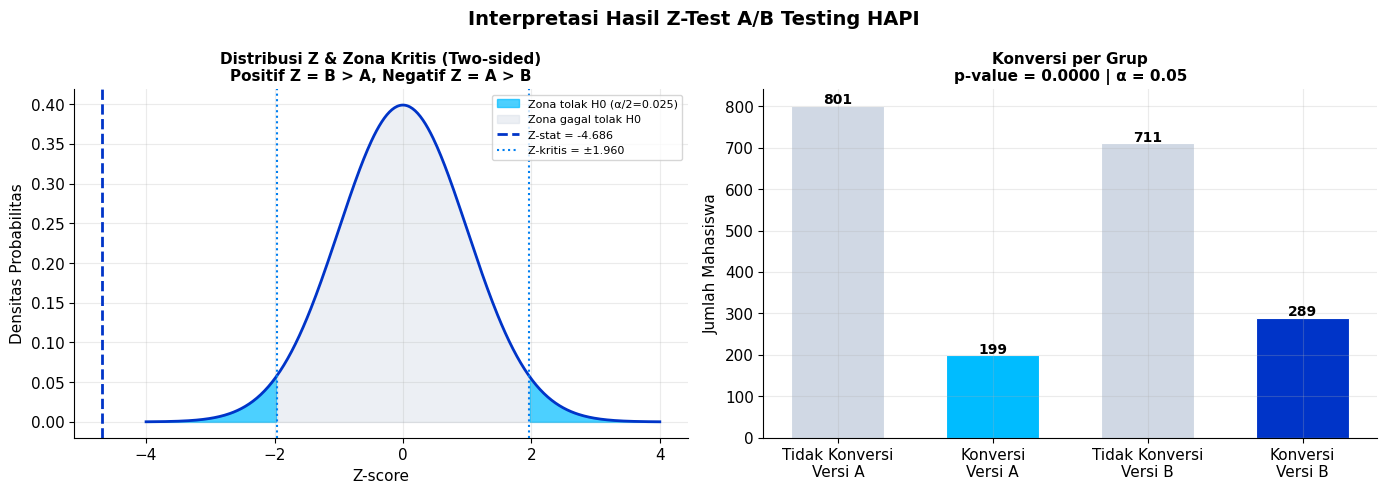

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_vals = np.linspace(-4, 4, 400)
y_vals = stats.norm.pdf(x_vals)

axes[0].plot(x_vals, y_vals, color=C_DARK, linewidth=2)
z_crit = stats.norm.ppf(1 - ALPHA/2)
x_left  = x_vals[x_vals <= -z_crit]
x_right = x_vals[x_vals >= z_crit]
axes[0].fill_between(x_left,  stats.norm.pdf(x_left),  color=C_LIGHT, alpha=0.7, label=f'Zona tolak H0 (α/2={ALPHA/2})')
axes[0].fill_between(x_right, stats.norm.pdf(x_right), color=C_LIGHT, alpha=0.7)
x_between = x_vals[(x_vals >= -z_crit) & (x_vals <= z_crit)]
axes[0].fill_between(x_between, stats.norm.pdf(x_between), color=C_GREY, alpha=0.4, label='Zona gagal tolak H0')
axes[0].axvline(z_statistic, color=C_DARK, linestyle='--', linewidth=2, label=f'Z-stat = {z_statistic:.3f}')
axes[0].axvline(-z_crit, color=C_MID, linestyle=':', linewidth=1.5, label=f'Z-kritis = ±{z_crit:.3f}')
axes[0].axvline(z_crit,  color=C_MID, linestyle=':', linewidth=1.5)
axes[0].set_xlabel('Z-score'); axes[0].set_ylabel('Densitas Probabilitas')
axes[0].set_title('Distribusi Z & Zona Kritis (Two-sided)\nPositif Z = B > A, Negatif Z = A > B',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
sns.despine(ax=axes[0])

categories = ['Tidak Konversi\nVersi A', 'Konversi\nVersi A', 'Tidak Konversi\nVersi B', 'Konversi\nVersi B']
values     = [jumlah_mahasiswa_A - konversi_A, konversi_A,
              jumlah_mahasiswa_B - konversi_B, konversi_B]
colors_bar = [C_GREY, C_LIGHT, C_GREY, C_DARK]
bars = axes[1].bar(categories, values, color=colors_bar, edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Jumlah Mahasiswa')
axes[1].set_title(f'Konversi per Grup\np-value = {p_value:.4f} | α = {ALPHA}',
                  fontsize=11, fontweight='bold')
sns.despine(ax=axes[1])

fig.suptitle('Interpretasi Hasil Z-Test A/B Testing HAPI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_interpretasi.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribusi Z & Zona Kritis**

Grafik kiri menampilkan distribusi normal standar dengan zona tolak H₀ di kedua ekor (warna terang `#00bcff`). Posisi Z-statistik eksperimen kita ditandai garis putus-putus gelap. Jika garis tersebut berada di **zona terang (ekor)**, kita tolak H₀; jika di **zona abu-abu (tengah)**, kita gagal menolak H₀.

## Bagian 6: Effect Size & Confidence Interval

In [9]:
diff = tingkat_konversi_B_diamati - tingkat_konversi_A_diamati
se   = np.sqrt(
    (tingkat_konversi_A_diamati*(1-tingkat_konversi_A_diamati)/jumlah_mahasiswa_A) +
    (tingkat_konversi_B_diamati*(1-tingkat_konversi_B_diamati)/jumlah_mahasiswa_B)
)
z_ci = stats.norm.ppf(1 - ALPHA/2)
ci_lower = diff - z_ci * se
ci_upper = diff + z_ci * se

p_pool = (konversi_A + konversi_B) / (jumlah_mahasiswa_A + jumlah_mahasiswa_B)
cohen_h = 2 * np.arcsin(np.sqrt(tingkat_konversi_B_diamati)) - 2 * np.arcsin(np.sqrt(tingkat_konversi_A_diamati))

print('EFFECT SIZE & CONFIDENCE INTERVAL')
print(f'\n  Selisih proporsi (B - A) : {diff:+.4f} ({diff*100:+.2f} poin persentase)')
print(f'  Standard Error           : {se:.4f}')
print(f'  95% Confidence Interval  : [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]')
print(f'  Cohen\'s h (effect size)  : {cohen_h:.4f}')
print()
if abs(cohen_h) < 0.2:
    es_label = 'Kecil (small)'
elif abs(cohen_h) < 0.5:
    es_label = 'Menengah (medium)'
else:
    es_label = 'Besar (large)'
print(f'  Interpretasi effect size : {es_label}')
print()
relative_uplift = (tingkat_konversi_B_diamati / tingkat_konversi_A_diamati - 1) * 100
print(f'  Relative uplift B vs A   : {relative_uplift:+.1f}%')

EFFECT SIZE & CONFIDENCE INTERVAL

  Selisih proporsi (B - A) : +0.0900 (+9.00 poin persentase)
  Standard Error           : 0.0191
  95% Confidence Interval  : [5.26%, 12.74%]
  Cohen's h (effect size)  : 0.2104

  Interpretasi effect size : Menengah (medium)

  Relative uplift B vs A   : +45.2%


**Effect Size & Confidence Interval**

Signifikansi statistik saja tidak cukup kita juga perlu tahu **seberapa besar** perbedaannya secara praktis:

- **95% CI** untuk selisih proporsi: jika interval tidak mencakup 0, perbedaan signifikan secara statistik
- **Cohen's h** mengukur *effect size* untuk proporsi: `|h| < 0.2` = kecil, `0.2-0.5` = menengah, `> 0.5` = besar
- **Relative uplift** menunjukkan peningkatan relatif Versi B terhadap Versi A lebih mudah dikomunikasikan ke pemangku kepentingan

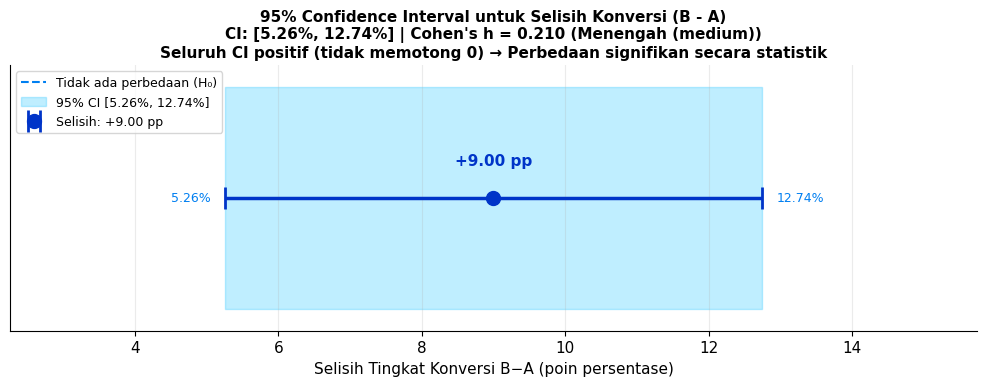

Selisih (B-A)    : +9.00 poin persentase
95% CI           : [5.26%, 12.74%]
CI memotong 0?   : TIDAK
Interpretasi     : Perbedaan SIGNIFIKAN (CI tidak memotong 0)


In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

xerr_left  = diff*100 - ci_lower*100
xerr_right = ci_upper*100 - diff*100

ax.errorbar(
    x=diff*100, y=0,
    xerr=[[xerr_left], [xerr_right]],
    fmt='o', color=C_DARK,
    markersize=10, markerfacecolor=C_DARK,
    capsize=8, capthick=2, linewidth=2.5,
    label=f'Selisih: {diff*100:+.2f} pp'
)

ax.axvline(0, color=C_MID, linestyle='--', linewidth=1.5, label='Tidak ada perbedaan (H₀)')

ax.fill_betweenx(
    y=[-0.5, 0.5],
    x1=ci_lower*100, x2=ci_upper*100,
    color=C_LIGHT, alpha=0.25, label=f'95% CI [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]'
)

ax.text(diff*100, 0.15, f'{diff*100:+.2f} pp', ha='center', fontsize=11, fontweight='bold', color=C_DARK)
ax.text(ci_lower*100 - 0.2, 0, f'{ci_lower*100:.2f}%', ha='right', va='center', fontsize=9, color=C_MID)
ax.text(ci_upper*100 + 0.2, 0, f'{ci_upper*100:.2f}%', ha='left',  va='center', fontsize=9, color=C_MID)

ax.set_xlim(ci_lower*100 - 3, ci_upper*100 + 3)
ax.set_ylim(-0.6, 0.6)
ax.set_yticks([])
ax.set_xlabel('Selisih Tingkat Konversi B−A (poin persentase)', fontsize=11)
ax.set_title(
    f'95% Confidence Interval untuk Selisih Konversi (B - A)\n'
    f'CI: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%] | Cohen\'s h = {cohen_h:.3f} ({es_label})\n'
    f'Seluruh CI positif (tidak memotong 0) → Perbedaan signifikan secara statistik',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9, loc='upper left')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('ab_confidence_interval.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Selisih (B-A)    : {diff*100:+.2f} poin persentase')
print(f'95% CI           : [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]')
print(f'CI memotong 0?   : {"YA" if ci_lower <= 0 <= ci_upper else "TIDAK"}')
print(f'Interpretasi     : {"Perbedaan SIGNIFIKAN (CI tidak memotong 0)" if not (ci_lower <= 0 <= ci_upper) else "Perbedaan TIDAK signifikan (CI mencakup 0)"}')

**Visualisasi Confidence Interval**

Error bar menampilkan 95% CI untuk selisih konversi. Jika interval sepenuhnya berada di sisi kanan garis nol, perbedaan signifikan secara statistik dan positif. Lebar interval mencerminkan presisi estimasi interval lebih sempit berarti estimasi lebih akurat.

## Bagian 7: Analisis Lanjutan — Sensitivitas & Segmentasi

In [11]:
alpha_values = [0.01, 0.05, 0.10]

col1 = 'Alpha'
col2 = 'Keputusan'
col3 = 'Kesimpulan'
print('ANALISIS SENSITIVITAS ALPHA')
print(f'{col1:>8} | {col2:>25} | {col3}')
print('-' * 65)
for a in alpha_values:
    if p_value <= a:
        kep = 'Tolak H0'
        kes = 'Signifikan -- implementasi Versi B'
    else:
        kep = 'Gagal Tolak H0'
        kes = 'Tidak signifikan -- pertahankan Versi A'
    marker = ' <-- DIGUNAKAN' if a == ALPHA else ''
    print(f'  {a:>6} | {kep:>25} | {kes}{marker}')


ANALISIS SENSITIVITAS ALPHA
   Alpha |                 Keputusan | Kesimpulan
-----------------------------------------------------------------
    0.01 |                  Tolak H0 | Signifikan -- implementasi Versi B
    0.05 |                  Tolak H0 | Signifikan -- implementasi Versi B <-- DIGUNAKAN
     0.1 |                  Tolak H0 | Signifikan -- implementasi Versi B


**Analisis Sensitivitas**

Menguji apakah keputusan berubah pada berbagai threshold alpha. Konsistensi hasil di berbagai alpha memberikan keyakinan lebih terhadap kesimpulan.

In [12]:
np.random.seed(42)
n_seg = 300
segments = {
    'Tahun 1 (Freshman)': {'A': 0.16, 'B': 0.26, 'n': n_seg},
    'Tahun 2-3 (Sophomore)': {'A': 0.20, 'B': 0.30, 'n': n_seg},
    'Tahun 4+ (Senior)': {'A': 0.24, 'B': 0.27, 'n': n_seg},
}

seg_results = []
for seg_name, params in segments.items():
    conv_a = np.random.binomial(1, params['A'], params['n']).sum()
    conv_b = np.random.binomial(1, params['B'], params['n']).sum()
    z, p = proportions_ztest([conv_a, conv_b], [params['n'], params['n']], alternative='two-sided')
    rate_a = conv_a / params['n']
    rate_b = conv_b / params['n']
    seg_results.append({
        'Segmen': seg_name,
        'Rate A': rate_a,
        'Rate B': rate_b,
        'Selisih (pp)': (rate_b - rate_a) * 100,
        'Z-stat': round(z, 3),
        'P-value': round(p, 4),
        'Signifikan': 'Ya' if p <= ALPHA else 'Tidak'
    })

df_seg = pd.DataFrame(seg_results)
print('ANALISIS SEGMENTASI PER TAHUN AKADEMIK')
print(df_seg.to_string(index=False))

ANALISIS SEGMENTASI PER TAHUN AKADEMIK
               Segmen  Rate A  Rate B  Selisih (pp)  Z-stat  P-value Signifikan
   Tahun 1 (Freshman)  0.1633  0.2867       12.3333 -3.6170   0.0003         Ya
Tahun 2-3 (Sophomore)  0.1700  0.3267       15.6667 -4.4410   0.0000         Ya
    Tahun 4+ (Senior)  0.2367  0.2500        1.3333 -0.3810   0.7035      Tidak


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12440\3723306134.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(seg_names, fontsize=9)


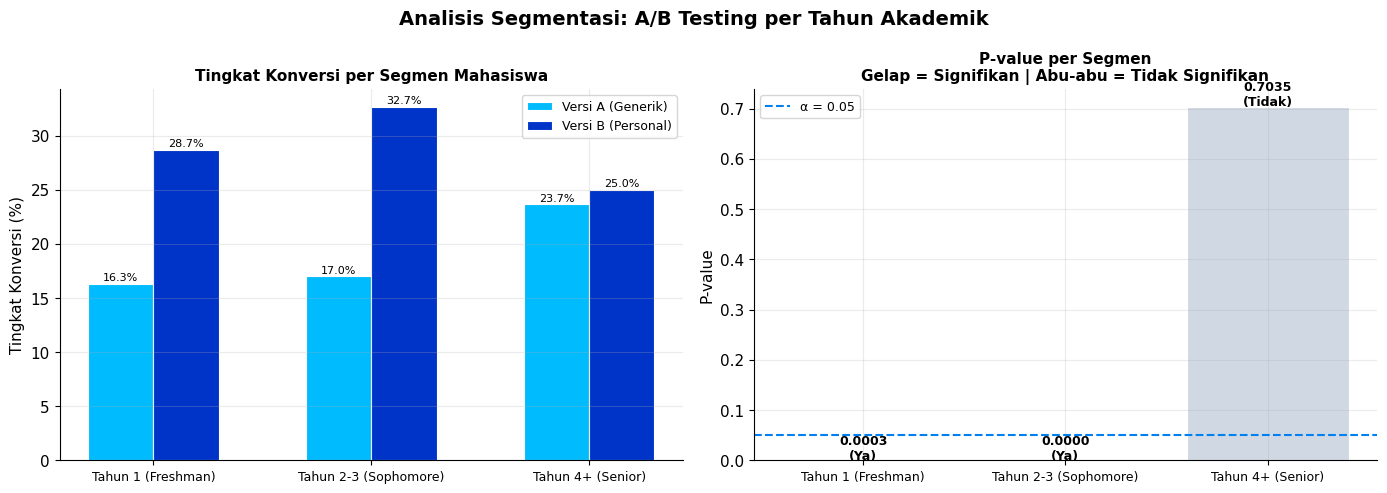

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_names = df_seg['Segmen'].tolist()
n_segs = len(seg_names)
x = np.arange(n_segs); w = 0.3

b1 = axes[0].bar(x - w/2, df_seg['Rate A']*100, w, label='Versi A (Generik)',
                 color=C_LIGHT, edgecolor='white', linewidth=0.8)
b2 = axes[0].bar(x + w/2, df_seg['Rate B']*100, w, label='Versi B (Personal)',
                 color=C_DARK, edgecolor='white', linewidth=0.8)
for bar in list(b1)+list(b2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(seg_names, fontsize=9)
axes[0].set_ylabel('Tingkat Konversi (%)')
axes[0].set_title('Tingkat Konversi per Segmen Mahasiswa', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

bar_colors_seg = [C_DARK if row['Signifikan']=='Ya' else C_GREY for _, row in df_seg.iterrows()]
bars_p = axes[1].bar(seg_names, df_seg['P-value'], color=bar_colors_seg, edgecolor='white', linewidth=0.8)
for bar, row in zip(bars_p, seg_results):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{row["P-value"]:.4f}\n({row["Signifikan"]})',
                 ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(ALPHA, color=C_MID, linestyle='--', linewidth=1.5, label=f'α = {ALPHA}')
axes[1].set_ylabel('P-value')
axes[1].set_title('P-value per Segmen\nGelap = Signifikan | Abu-abu = Tidak Signifikan',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticklabels(seg_names, fontsize=9)
sns.despine(ax=axes[1])

fig.suptitle('Analisis Segmentasi: A/B Testing per Tahun Akademik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ab_segmentasi.png', dpi=150, bbox_inches='tight')
plt.show()

**Analisis Segmentasi**

Hasil keseluruhan mungkin berbeda dari hasil per segmen efek yang tidak signifikan secara keseluruhan bisa jadi signifikan pada segmen tertentu (*heterogeneous treatment effect*). Ini penting untuk menentukan apakah rollout perlu dilakukan secara universal atau bertahap per segmen.

## Bagian 8: Keputusan Bisnis & Rekomendasi

In [14]:
print('RINGKASAN EKSEKUTIF A/B TESTING HAPI')
print()
print(f'Eksperimen   : Intervensi Generik (A) vs Intervensi Personal (B)')
print(f'Sampel total : {jumlah_mahasiswa_A + jumlah_mahasiswa_B:,} mahasiswa')
print(f'Periode      : 4 minggu')
print()
print(f'Tingkat konversi A : {tingkat_konversi_A_diamati*100:.2f}%')
print(f'Tingkat konversi B : {tingkat_konversi_B_diamati*100:.2f}%')
print(f'Selisih            : {(tingkat_konversi_B_diamati - tingkat_konversi_A_diamati)*100:+.2f} pp')
print(f'Relative uplift    : {relative_uplift:+.1f}%')
print()
print(f'Z-statistik        : {z_statistic:.4f}')
print(f'P-value            : {p_value:.4f}')
print(f'Alpha (α)          : {ALPHA}')
print(f'95% CI selisih     : [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]')
print(f'Cohen\'s h          : {cohen_h:.4f} ({es_label})')
print()
print(f'KEPUTUSAN STATISTIK: {keputusan}')
print(f'KESIMPULAN         : {kesimpulan}')

RINGKASAN EKSEKUTIF A/B TESTING HAPI

Eksperimen   : Intervensi Generik (A) vs Intervensi Personal (B)
Sampel total : 2,000 mahasiswa
Periode      : 4 minggu

Tingkat konversi A : 19.90%
Tingkat konversi B : 28.90%
Selisih            : +9.00 pp
Relative uplift    : +45.2%

Z-statistik        : -4.6857
P-value            : 0.0000
Alpha (α)          : 0.05
95% CI selisih     : [5.26%, 12.74%]
Cohen's h          : 0.2104 (Menengah (medium))

KEPUTUSAN STATISTIK: TOLAK H0
KESIMPULAN         : Terdapat perbedaan yang SIGNIFIKAN secara statistik


In [15]:
print('REKOMENDASI BISNIS')
print()
if p_value <= ALPHA and tingkat_konversi_B_diamati > tingkat_konversi_A_diamati:
    print('SKENARIO A: Hasil Signifikan & Positif → IMPLEMENTASI VERSI B')
    print()
    print('1. ROLLOUT BERTAHAP')
    print('   → Terapkan intervensi personal ke semua mahasiswa secara bertahap')
    print('   → Mulai dari segmen dengan efek terbesar berdasarkan analisis segmentasi')
    print()
    print('2. MONITORING POST-LAUNCH')
    print('   → Pantau conversion rate mingguan selama 4 minggu pertama')
    print('   → Tetapkan alert jika konversi turun >2 poin dari baseline')
    print()
    print('3. ITERASI BERIKUTNYA')
    print('   → Uji personalisasi yang lebih granular (berdasarkan risk level, bukan hanya fatigue score)')
    print('   → Target selanjutnya: konversi B > 35% dalam 8 minggu')
else:
    print('SKENARIO B: Hasil Tidak Signifikan → TIDAK MELUNCURKAN, INVESTIGASI')
    print()
    print('1. TIDAK MELUNCURKAN (DEFAULT ACTION)')
    print('   → Jangan implementasi Versi B tanpa bukti signifikan')
    print('   → Pertahankan Versi A sampai ada bukti yang lebih kuat')
    print()
    print('2. OPSI INVESTIGASI')
    print('   A. Tambah sampel/durasi: kemungkinan ukuran sampel kurang besar')
    print('   B. Analisis segmentasi: mungkin efek hanya ada pada sub-kelompok tertentu')
    print('   C. Revisi intervensi: rancang ulang pesan personalisasi yang lebih relevan')
    print()
    print('3. PERTIMBANGAN LANJUTAN')
    print('   → Apakah metrik yang dipilih (conversion rate) sudah tepat?')
    print('   → Apakah periode eksperimen cukup panjang untuk mendeteksi efek?')

REKOMENDASI BISNIS

SKENARIO A: Hasil Signifikan & Positif → IMPLEMENTASI VERSI B

1. ROLLOUT BERTAHAP
   → Terapkan intervensi personal ke semua mahasiswa secara bertahap
   → Mulai dari segmen dengan efek terbesar berdasarkan analisis segmentasi

2. MONITORING POST-LAUNCH
   → Pantau conversion rate mingguan selama 4 minggu pertama
   → Tetapkan alert jika konversi turun >2 poin dari baseline

3. ITERASI BERIKUTNYA
   → Uji personalisasi yang lebih granular (berdasarkan risk level, bukan hanya fatigue score)
   → Target selanjutnya: konversi B > 35% dalam 8 minggu


**Keputusan Bisnis berbasis Data**

Dalam era data, pengambilan keputusan yang efektif didorong oleh bukti statistik yang solid, bukan sekadar intuisi. Framework ini memastikan bahwa setiap keputusan produk HAPI apakah meluncurkan fitur baru atau mempertahankan yang lama — dilandasi oleh metodologi eksperimental yang ketat dan terukur.

## Ringkasan KPI A/B Testing

In [16]:
print('KPI A/B TESTING HAPI')
print()
kpis = [
    ('Tingkat konversi A (baseline)', f'{tingkat_konversi_A_diamati*100:.2f}%'),
    ('Tingkat konversi B (perlakuan)', f'{tingkat_konversi_B_diamati*100:.2f}%'),
    ('Peningkatan absolut', f'{(tingkat_konversi_B_diamati - tingkat_konversi_A_diamati)*100:+.2f} poin persentase'),
    ('Relative uplift', f'{relative_uplift:+.1f}%'),
    ('Z-statistik', f'{z_statistic:.4f}'),
    ('P-value', f'{p_value:.4f}'),
    ('95% CI selisih', f'[{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]'),
    ('Cohen\'s h (effect size)', f'{cohen_h:.4f} — {es_label}'),
    ('Keputusan statistik', keputusan),
]
for kpi, val in kpis:
    print(f'  {kpi:<40}: {val}')
print()
print('Validasi Chi-square konsisten dengan Z-test:', 'YA' if (p_value < ALPHA) == (p_chi2 < ALPHA) else 'TIDAK')

KPI A/B TESTING HAPI

  Tingkat konversi A (baseline)           : 19.90%
  Tingkat konversi B (perlakuan)          : 28.90%
  Peningkatan absolut                     : +9.00 poin persentase
  Relative uplift                         : +45.2%
  Z-statistik                             : -4.6857
  P-value                                 : 0.0000
  95% CI selisih                          : [5.26%, 12.74%]
  Cohen's h (effect size)                 : 0.2104 — Menengah (medium)
  Keputusan statistik                     : TOLAK H0

Validasi Chi-square konsisten dengan Z-test: YA


**Ringkasan KPI**

| KPI | Keterangan |
|---|---|
| Tingkat konversi | Metrik primer, % mahasiswa yang mengakses fitur wellness |
| P-value | Probabilitas mendapatkan hasil ini jika H₀ benar |
| 95% CI | Rentang nilai selisih yang dapat kita percayai dengan 95% keyakinan |
| Cohen's h | Ukuran efek praktis, seberapa besar perbedaan secara substantif |
| Keputusan statistik | Kesimpulan formal berdasarkan perbandingan p-value dengan α |